# 01. 2024·2025 교통카드 데이터 EDA

두 기준일의 데이터 구조, 노선 수, 결측치, 이용량을 확인한다.

In [64]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap
from matplotlib import font_manager

# 노트북을 Analysis 폴더 또는 저장소 루트에서 실행해도 동작하도록 설정
ROOT = Path.cwd()
if not (ROOT / 'gtx_a_seoul_bus_outputs').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'gtx_a_seoul_bus_outputs' / 'transport_card'
FILE_2024 = DATA_DIR / 'gtx_a_transport_card_20241017_raw_with_coords_api_filled.csv'
FILE_2025 = DATA_DIR / 'gtx_a_transport_card_20251016_raw_with_coords.csv'

# Windows 한글 폰트 우선 적용
font_candidates = ['Malgun Gothic', 'NanumGothic', 'AppleGothic']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break
plt.rcParams['axes.unicode_minus'] = False

df24 = pd.read_csv(FILE_2024, encoding='utf-8-sig')
df25 = pd.read_csv(FILE_2025, encoding='utf-8-sig')
for df in (df24, df25):
    df['utztn_nope'] = pd.to_numeric(df['utztn_nope'], errors='coerce')
    df['utztn_dstnc'] = pd.to_numeric(df['utztn_dstnc'], errors='coerce')
print(f'2024: {df24.shape}, 2025: {df25.shape}')

2024: (12109, 33), 2025: (10117, 33)


## 기본 구조와 노선별 이용량

In [65]:
route_summary = pd.DataFrame({
    '2024 행 수': df24.groupby('query_route_no').size(),
    '2025 행 수': df25.groupby('query_route_no').size(),
    '2024 이용인원': df24.groupby('query_route_no')['utztn_nope'].sum(),
    '2025 이용인원': df25.groupby('query_route_no')['utztn_nope'].sum(),
}).fillna(0).sort_index()
route_summary['증감률(%)'] = np.where(
    route_summary['2024 이용인원'] != 0,
    (route_summary['2025 이용인원'] - route_summary['2024 이용인원']) / route_summary['2024 이용인원'] * 100,
    np.nan,
)
display(route_summary)

,2024 행 수,2025 행 수,2024 이용인원,2025 이용인원,증감률(%)
query_route_no,,,,,
1000,3104,2712,7797,6779,-13.056304
1082,520,442,1309,1111,-15.126050
1100,37,21,99,54,-45.454545
1200,1058,769,2629,1907,-27.462914
1500,1350,1040,3385,2572,-24.017725
1900,54,44,130,104,-20.000000
2200,857,691,2116,1744,-17.580340
3100,471,386,1209,963,-20.347395
3400,397,273,967,706,-26.990693


,2024,2025
승차정류장순서,181,0
하차정류장순서,160,0


,2024,2025,증감 인원
query_route_no,,,
1000,7797,6779,-1018
M7111,1319,491,-828
1500,3385,2572,-813
1200,2629,1907,-722
2200,2116,1744,-372
G7426,941,672,-269
G7625,709,444,-265
3400,967,706,-261
3100,1209,963,-246


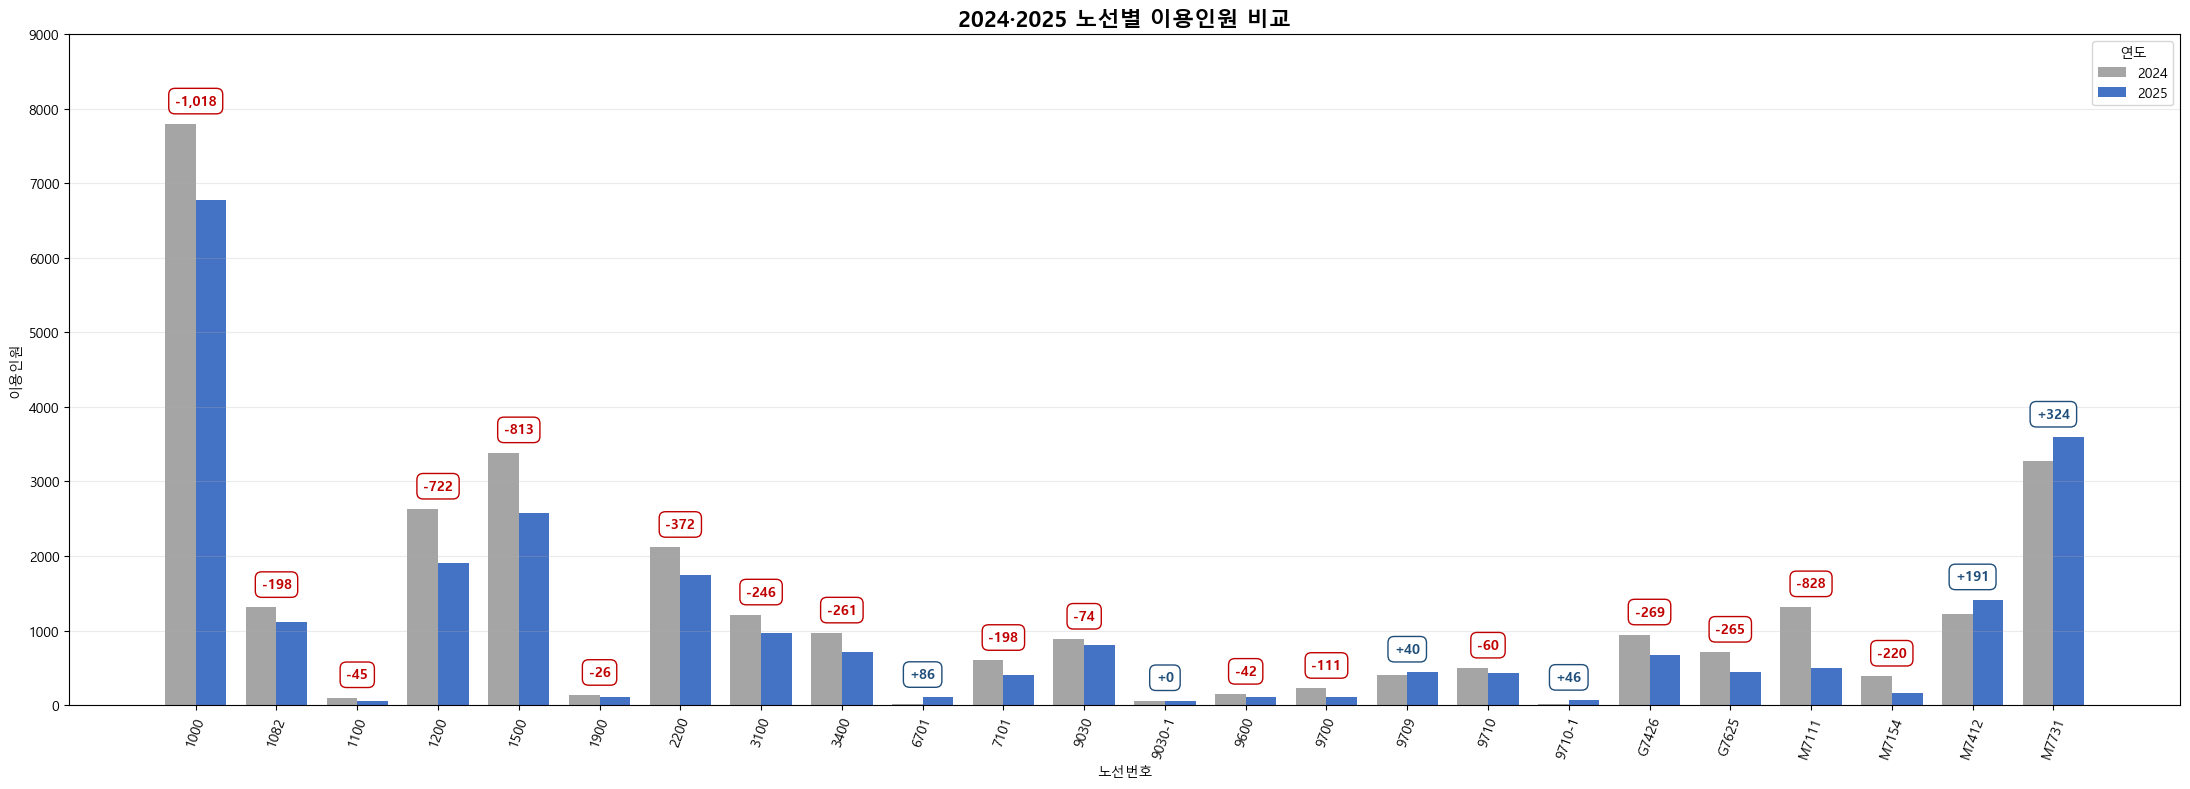

In [66]:
missing = pd.DataFrame({
    2024: df24.isna().sum(),
    2025: df25.isna().sum(),
})
display(missing[missing.sum(axis=1) > 0].sort_values(2024, ascending=False))

demand24 = df24.groupby('query_route_no')['utztn_nope'].sum()
demand25 = df25.groupby('query_route_no')['utztn_nope'].sum()
all_routes = sorted(set(demand24.index) | set(demand25.index), key=str)
comparison = pd.DataFrame({'2024': demand24, '2025': demand25}).reindex(all_routes, fill_value=0)
comparison['\uC99D\uAC10 \uC778\uC6D0'] = comparison['2025'] - comparison['2024']
display(comparison.sort_values('\uC99D\uAC10 \uC778\uC6D0'))

x = np.arange(len(comparison))
width = 0.38
fig, ax = plt.subplots(figsize=(22, 8))
bars24 = ax.bar(x - width / 2, comparison['2024'], width, label='2024', color='#A5A5A5')
bars25 = ax.bar(x + width / 2, comparison['2025'], width, label='2025', color='#4472C4')
ax.set_title('2024\u00B72025 \uB178\uC120\uBCC4 \uC774\uC6A9\uC778\uC6D0 \uBE44\uAD50', fontsize=16, fontweight='bold')
ax.set_xlabel('\uB178\uC120\uBC88\uD638')
ax.set_ylabel('\uC774\uC6A9\uC778\uC6D0')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=70)
ax.set_ylim(0, 9000)
ax.legend(title='\uC5F0\uB3C4')
ax.grid(axis='y', alpha=0.25)

for i, value in enumerate(comparison['\uC99D\uAC10 \uC778\uC6D0']):
    ymax = max(comparison.iloc[i]['2024'], comparison.iloc[i]['2025'])
    color = '#C00000' if value < 0 else '#1F4E79'
    ax.text(i, min(ymax + 220, 8650), f'{value:+,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=color, bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor=color, linewidth=1.0))
plt.tight_layout()
plt.show()

## 2024·2025 노선 구성 비교

,2024·2025 공통,2024년에만 존재,2025년에만 존재
0,1000,NaN,NaN
1,1082,NaN,NaN
2,1100,NaN,NaN
3,1200,NaN,NaN
4,1500,NaN,NaN
5,1900,NaN,NaN
6,2200,NaN,NaN
7,3100,NaN,NaN
8,3400,NaN,NaN
9,6701,NaN,NaN


2024 노선 수: 24 / 2025 노선 수: 24


,2024,2025,증감,증감률(%)
query_route_no,,,,
M7731,3271,3595,324,9.905228
M7412,1221,1412,191,15.642916
6701,16,102,86,537.500000
9710-1,18,64,46,255.555556
9709,402,442,40,9.950249
9030-1,59,59,0,0.000000
1900,130,104,-26,-20.000000
9600,145,103,-42,-28.965517
1100,99,54,-45,-45.454545


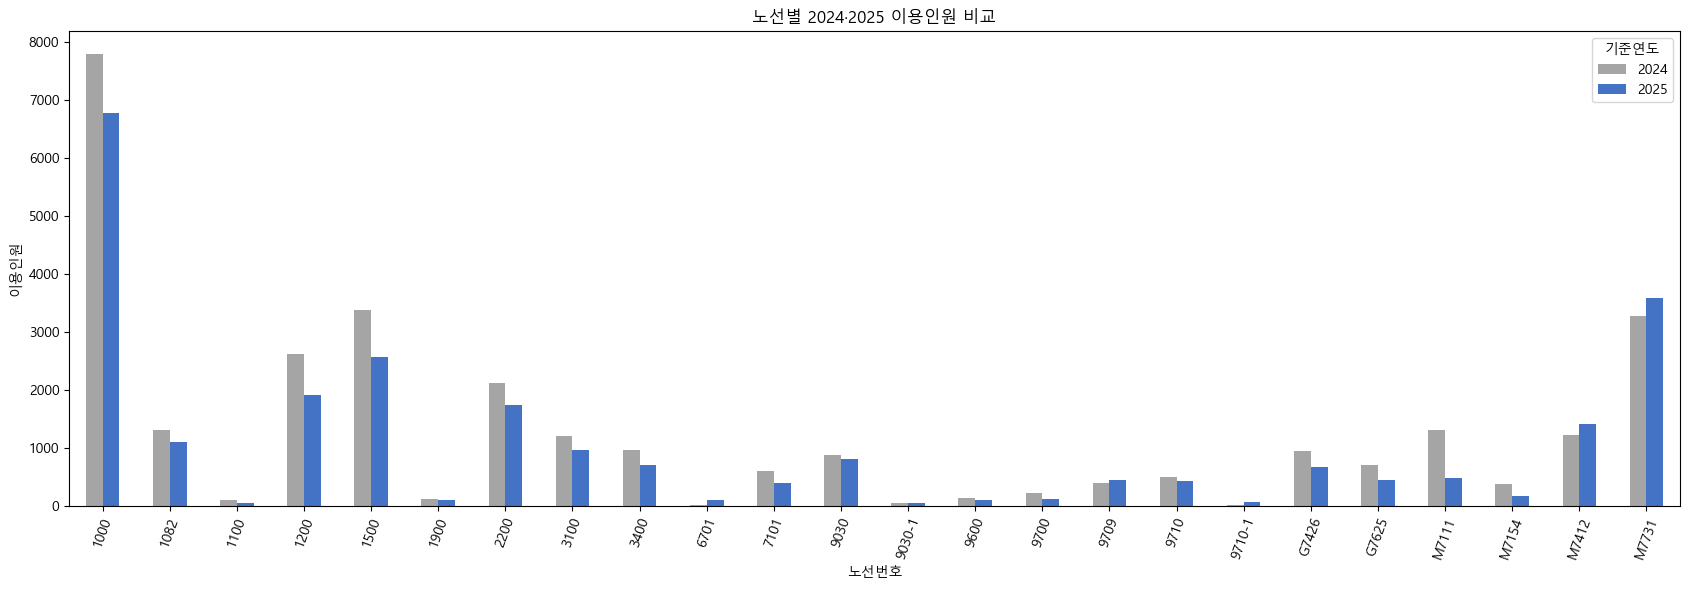

In [67]:
routes24 = set(df24['query_route_no'].dropna().astype(str))
routes25 = set(df25['query_route_no'].dropna().astype(str))
route_comparison = pd.DataFrame({
    '2024·2025 공통': pd.Series(sorted(routes24 & routes25, key=str)),
    '2024년에만 존재': pd.Series(sorted(routes24 - routes25, key=str)),
    '2025년에만 존재': pd.Series(sorted(routes25 - routes24, key=str)),
})
display(route_comparison)
print(f'2024 노선 수: {len(routes24)} / 2025 노선 수: {len(routes25)}')

demand = pd.DataFrame({
    '2024': df24.groupby('query_route_no')['utztn_nope'].sum(),
    '2025': df25.groupby('query_route_no')['utztn_nope'].sum(),
}).fillna(0)
demand['증감'] = demand['2025'] - demand['2024']
demand['증감률(%)'] = np.where(demand['2024'] != 0, demand['증감'] / demand['2024'] * 100, np.nan)
display(demand.sort_values('증감', ascending=False))

ax = demand[['2024', '2025']].sort_index().plot.bar(figsize=(17, 6), color=['#A5A5A5', '#4472C4'])
ax.set_title('노선별 2024·2025 이용인원 비교')
ax.set_xlabel('노선번호')
ax.set_ylabel('이용인원')
ax.tick_params(axis='x', rotation=70)
ax.legend(title='기준연도')
plt.tight_layout()
plt.show()

## 정류장별 수요 시각화

===== 2024 승차 상위 정류장 =====


,,이용인원,위도,경도,이용건수
ride_sttn_id,승차정류장명,,,,
4106821,마두역(중),1510,37.652333,126.777467,620
4196170,행신초등학교.더자인병원(중),1402,37.622150,126.837500,554
4111341,고양경찰서.토당청소년수련관(중),1388,37.626700,126.830200,562
4106859,일산동구청(중),1203,37.657400,126.774667,483
4104784,새암공원,1123,37.711383,126.746083,436
4127137,대화역(중),1123,37.676100,126.747483,460
4106852,주엽역(중),1102,37.670033,126.761633,418
4177532,킨텍스,1036,37.667933,126.741517,424
4110865,백석동.요진와이시티(중),1022,37.641033,126.790567,397


===== 2024 하차 상위 정류장 =====


,,이용인원,위도,경도,이용건수
goff_sttn_id,하차정류장명,,,,
4111612,광화문역6번출구.광화문빌딩,4284,37.569517,126.976750,1706
4111588,합정역,4258,37.551133,126.915717,1729
4151598,연세대앞(중),3428,37.559967,126.935333,1350
4100727,당산역.삼성래미안아파트,3205,37.533033,126.903367,1285
4111614,신한은행본점,1707,37.561117,126.975517,681
4151586,디지털미디어시티역(중),1466,37.579067,126.900550,580
4108423,숭례문,1294,37.558117,126.973117,525
4116126,홍대입구역(중),953,37.557383,126.924400,374
4100733,영등포시장역4번출구,918,37.521433,126.904750,362


===== 2025 승차 상위 정류장 =====


,,이용인원,위도,경도,이용건수
ride_sttn_id,승차정류장명,,,,
4106836,대화역,1570,37.676367,126.747500,623
4196170,행신초등학교.더자인병원(중),1359,37.622150,126.837500,548
4111341,고양경찰서.토당청소년수련관(중),1343,37.626700,126.830200,538
4106821,마두역(중),1150,37.652333,126.777467,480
4104784,새암공원,982,37.711383,126.746083,392
4106859,일산동구청(중),955,37.657400,126.774667,384
4177448,킨텍스역.더샵그라비스타.힐스테이트일산,945,37.663850,126.747050,381
4110865,백석동.요진와이시티(중),908,37.641033,126.790567,355
4106852,주엽역(중),806,37.670033,126.761633,312


===== 2025 하차 상위 정류장 =====


,,이용인원,위도,경도,이용건수
goff_sttn_id,하차정류장명,,,,
4111588,합정역,3719,37.551133,126.915717,1489
4151598,연세대앞(중),3337,37.559967,126.935333,1351
4111612,광화문역6번출구.광화문빌딩,3058,37.569517,126.976750,1223
4100727,당산역.삼성래미안아파트,2517,37.533033,126.903367,1009
4116126,홍대입구역(중),1269,37.557383,126.924400,522
4151586,디지털미디어시티역(중),1253,37.579067,126.900550,483
4111614,신한은행본점,1167,37.561117,126.975517,475
4100733,영등포시장역4번출구,714,37.521433,126.904750,295
4199061,CM병원,709,37.518350,126.902967,277


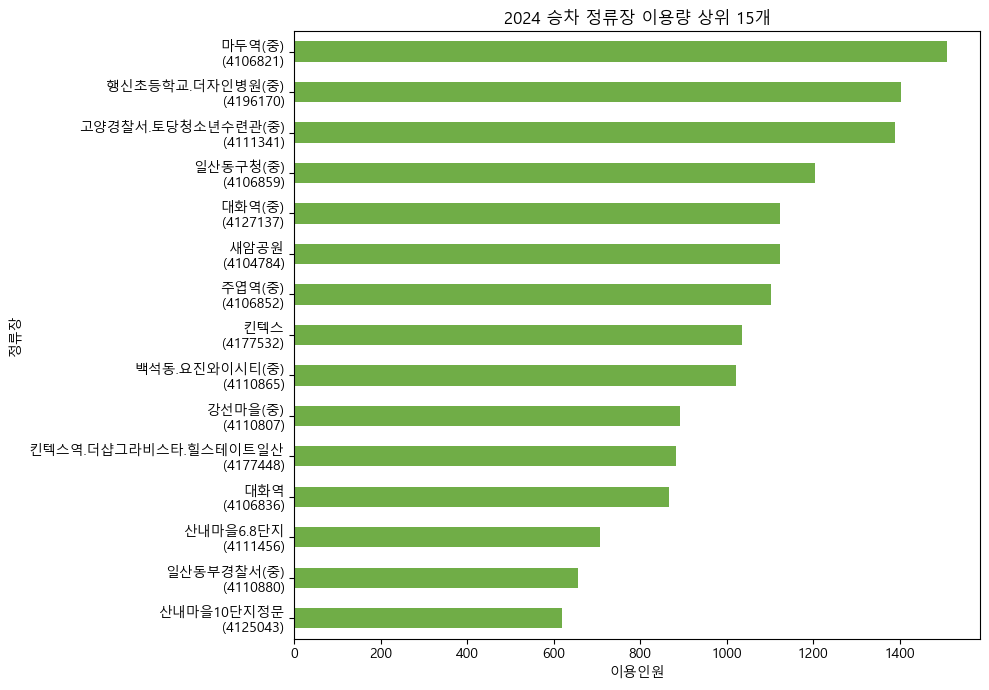

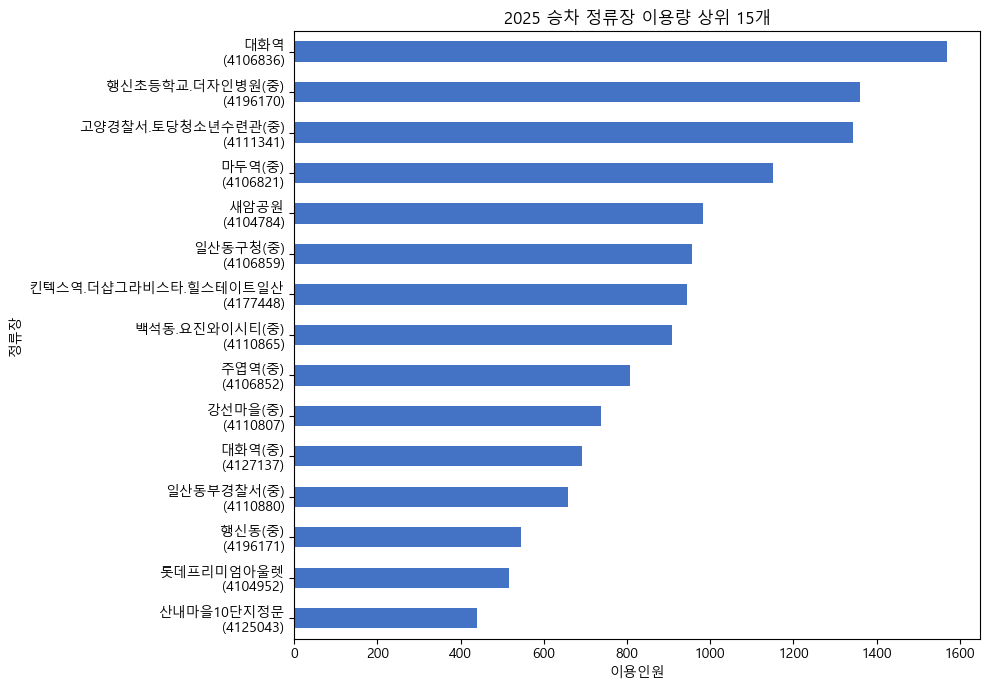

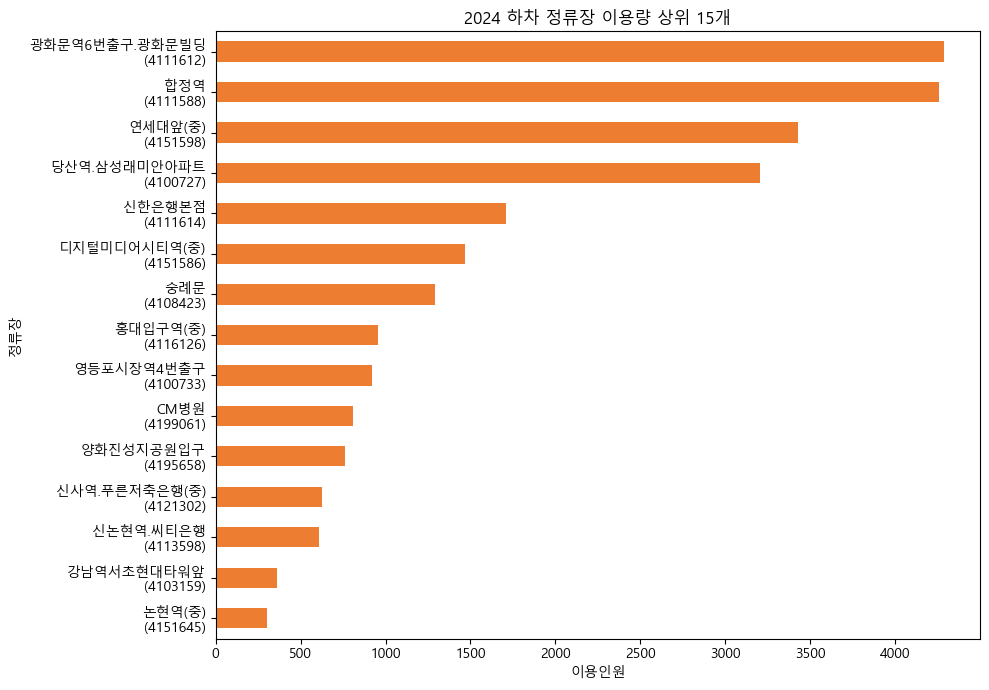

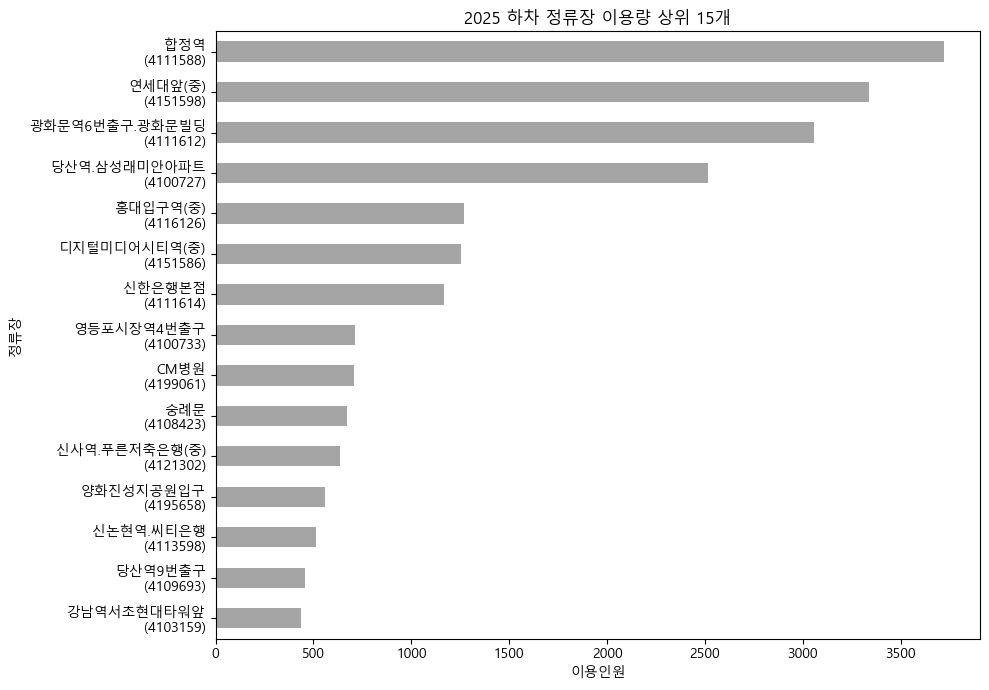

In [68]:
def stop_summary(df, id_col, name_col, lat_col, lon_col, n=15):
    return (df.groupby([id_col, name_col], dropna=False)
              .agg(이용인원=('utztn_nope', 'sum'), 위도=(lat_col, 'first'), 경도=(lon_col, 'first'), 이용건수=('utztn_nope', 'size'))
              .sort_values('이용인원', ascending=False).head(n))

for year, df in [('2024', df24), ('2025', df25)]:
    print(f'===== {year} 승차 상위 정류장 =====')
    display(stop_summary(df, 'ride_sttn_id', '승차정류장명', '승차위도', '승차경도'))
    print(f'===== {year} 하차 상위 정류장 =====')
    display(stop_summary(df, 'goff_sttn_id', '하차정류장명', '하차위도', '하차경도'))

def plot_top_stops(df, year, id_col, name_col, title, color):
    s = df.groupby([id_col, name_col])['utztn_nope'].sum().sort_values(ascending=False).head(15).sort_values()
    labels = [f'{idx[1]}\n({idx[0]})' for idx in s.index]
    ax = s.set_axis(labels).plot.barh(figsize=(10, 7), color=color)
    ax.set_title(f'{year} {title} 상위 15개')
    ax.set_xlabel('이용인원')
    ax.set_ylabel('정류장')
    plt.tight_layout()
    plt.show()

plot_top_stops(df24, '2024', 'ride_sttn_id', '승차정류장명', '승차 정류장 이용량', '#70AD47')
plot_top_stops(df25, '2025', 'ride_sttn_id', '승차정류장명', '승차 정류장 이용량', '#4472C4')
plot_top_stops(df24, '2024', 'goff_sttn_id', '하차정류장명', '하차 정류장 이용량', '#ED7D31')
plot_top_stops(df25, '2025', 'goff_sttn_id', '하차정류장명', '하차 정류장 이용량', '#A5A5A5')

## 노선별 시간대 이용자 수

In [69]:
FIRST_SERVICE_HOUR = 4  # 두 기준일의 실제 첫차 시간대 기준

def hourly_route_counts(df):
    work = df.copy()
    work['승차시간'] = pd.to_datetime(work['ride_dt'].astype(str), format='%Y%m%d%H%M%S', errors='coerce').dt.hour
    work = work.dropna(subset=['승차시간', 'query_route_no'])
    work['승차시간'] = work['승차시간'].astype(int)
    hourly = (work.groupby(['query_route_no', '승차시간'])['utztn_nope']
                   .sum().rename('이용인원').reset_index())
    count_table = hourly.pivot(index='query_route_no', columns='승차시간', values='이용인원').fillna(0)
    # 0~3시는 심야 잔여 기록이므로 제외하고 첫차 시간대부터 표시
    active_hours = sorted(h for h in hourly['승차시간'].unique() if h >= FIRST_SERVICE_HOUR)
    count_table = count_table.reindex(columns=active_hours, fill_value=0)
    return hourly, count_table, active_hours

hourly24, hourly_count24, hours24 = hourly_route_counts(df24)
hourly25, hourly_count25, hours25 = hourly_route_counts(df25)

# 각 노선×시간대의 실제 이용자 수
display(hourly_count24.astype(int).rename_axis('2024 노선'))
display(hourly_count25.astype(int).rename_axis('2025 노선'))

승차시간,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
2024 노선,,,,,,,,,,,,,,,,,,,,
1000,113,369,775,1415,811,500,481,402,330,313,310,227,273,408,293,181,175,185,159,72
1082,0,114,182,169,148,63,59,66,65,20,53,43,65,84,48,40,25,42,23,0
1100,0,6,6,48,11,2,4,4,7,1,3,0,0,4,3,0,0,0,0,0
1200,23,112,353,610,231,229,166,135,91,95,62,61,89,115,69,45,41,38,33,19
1500,4,153,258,340,306,138,144,141,136,150,147,147,216,224,247,183,119,141,133,53
1900,1,19,4,29,24,7,2,4,3,7,3,0,7,6,0,0,0,6,4,4
2200,0,56,156,187,140,114,65,96,69,82,49,84,140,292,218,126,65,131,33,13
3100,4,82,164,161,134,83,53,86,53,64,19,47,48,62,48,32,14,29,9,11
3400,11,69,148,260,118,86,41,56,19,16,25,12,29,43,11,5,9,3,4,2


승차시간,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
2025 노선,,,,,,,,,,,,,,,,,,,,
1000,115,378,611,1367,741,466,311,328,300,268,225,212,290,280,284,143,117,124,131,78
1082,0,88,156,187,128,95,48,45,52,47,36,16,63,40,30,16,15,23,16,8
1100,0,4,27,8,0,3,0,0,0,0,0,0,1,6,5,0,0,0,0,0
1200,15,106,263,420,183,132,95,115,71,64,45,59,60,60,59,36,29,43,33,13
1500,6,120,270,173,209,106,89,132,131,129,98,104,153,192,238,101,94,112,76,30
1900,0,2,2,31,9,8,1,7,6,1,3,4,12,3,0,7,5,1,0,0
2200,10,55,55,93,84,78,69,72,62,60,67,116,113,180,279,155,67,104,12,13
3100,14,58,108,121,97,55,34,49,67,45,39,20,42,56,56,27,36,19,19,1
3400,10,37,130,132,93,31,43,32,21,9,18,17,23,41,27,13,14,4,5,6


,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
노선번호,,,,,,,,,,,,,,,,,,,,
1000,2.0,9.0,-164.0,-48.0,-70.0,-34.0,-170.0,-74.0,-30.0,-45.0,-85.0,-15.0,17.0,-128.0,-9.0,-38.0,-58.0,-61.0,-28.0,6.0
1082,0.0,-26.0,-26.0,18.0,-20.0,32.0,-11.0,-21.0,-13.0,27.0,-17.0,-27.0,-2.0,-44.0,-18.0,-24.0,-10.0,-19.0,-7.0,8.0
1100,0.0,-2.0,21.0,-40.0,-11.0,1.0,-4.0,-4.0,-7.0,-1.0,-3.0,0.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
1200,-8.0,-6.0,-90.0,-190.0,-48.0,-97.0,-71.0,-20.0,-20.0,-31.0,-17.0,-2.0,-29.0,-55.0,-10.0,-9.0,-12.0,5.0,0.0,-6.0
1500,2.0,-33.0,12.0,-167.0,-97.0,-32.0,-55.0,-9.0,-5.0,-21.0,-49.0,-43.0,-63.0,-32.0,-9.0,-82.0,-25.0,-29.0,-57.0,-23.0
1900,-1.0,-17.0,-2.0,2.0,-15.0,1.0,-1.0,3.0,3.0,-6.0,0.0,4.0,5.0,-3.0,0.0,7.0,5.0,-5.0,-4.0,-4.0
2200,10.0,-1.0,-101.0,-94.0,-56.0,-36.0,4.0,-24.0,-7.0,-22.0,18.0,32.0,-27.0,-112.0,61.0,29.0,2.0,-27.0,-21.0,0.0
3100,10.0,-24.0,-56.0,-40.0,-37.0,-28.0,-19.0,-37.0,14.0,-19.0,20.0,-27.0,-6.0,-6.0,8.0,-5.0,22.0,-10.0,10.0,-10.0
3400,-1.0,-32.0,-18.0,-128.0,-25.0,-55.0,2.0,-24.0,2.0,-7.0,-7.0,5.0,-6.0,-2.0,16.0,8.0,5.0,1.0,1.0,4.0


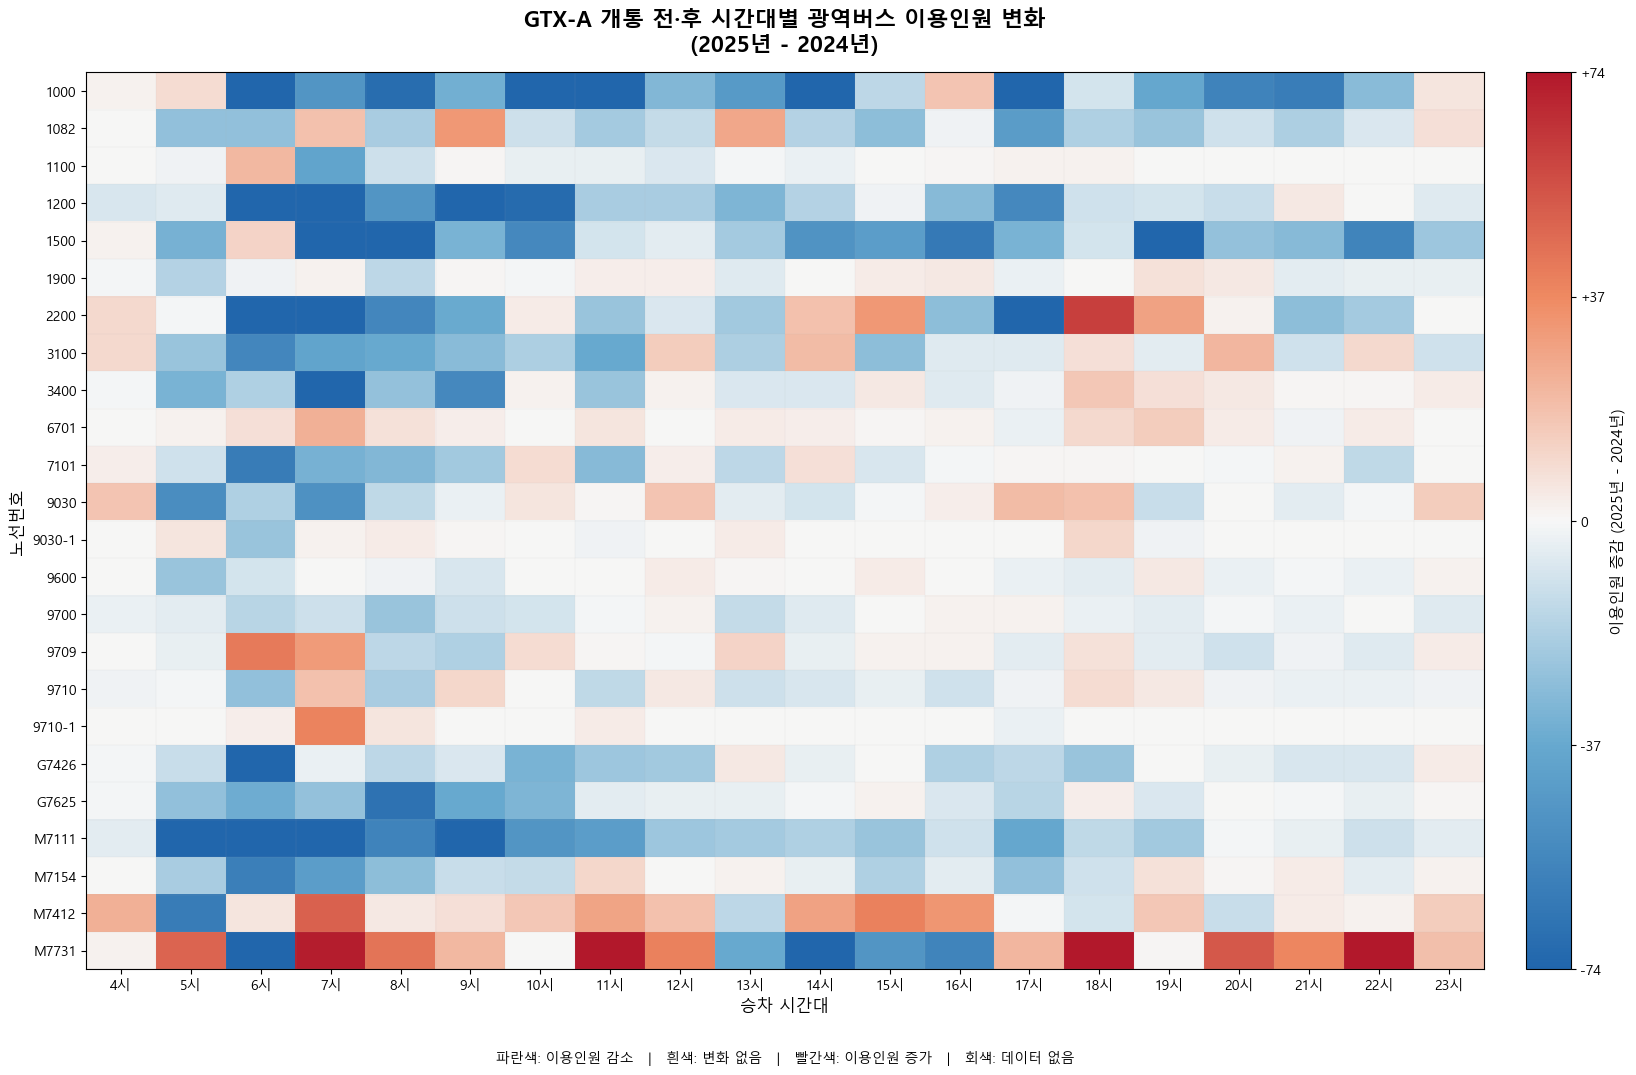

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# ============================================================
# 1. 시간대 컬럼 정리
# ============================================================

def clean_hour(x):
    """
    4, '4', '4시', '04시' 등 어떤 형태든 정수 시간으로 변환
    """
    s = str(x).strip()
    s = s.replace('시', '')
    
    try:
        return int(float(s))
    except:
        return np.nan


# 원본 복사
h24 = hourly_count24.copy()
h25 = hourly_count25.copy()

# 시간 컬럼을 정수로 통일
h24.columns = [clean_hour(c) for c in h24.columns]
h25.columns = [clean_hour(c) for c in h25.columns]

# 변환 실패 컬럼 제거
h24 = h24.loc[:, pd.notna(h24.columns)]
h25 = h25.loc[:, pd.notna(h25.columns)]

h24.columns = h24.columns.astype(int)
h25.columns = h25.columns.astype(int)


# ============================================================
# 2. 분석 시간대 설정
#    필요하면 4~23시 범위 수정
# ============================================================

all_hours = list(range(4, 24))

all_routes = sorted(
    set(h24.index.astype(str)) | set(h25.index.astype(str)),
    key=str
)

h24.index = h24.index.astype(str)
h25.index = h25.index.astype(str)


# ============================================================
# 3. 2024 / 2025 데이터 정렬
#
# 중요:
# reindex에서 처음부터 fill_value=0을 사용하지 않음.
# 노선/시간대 자체가 없었던 경우와 실제 이용자 0명을 구분하기 위함.
# ============================================================

h24_aligned = h24.reindex(
    index=all_routes,
    columns=all_hours
)

h25_aligned = h25.reindex(
    index=all_routes,
    columns=all_hours
)


# ============================================================
# 4. 비교 가능한 셀만 변화량 계산
#
# 두 연도 중 하나라도 데이터가 존재하면 비교
# 둘 다 NaN이면 미운행/데이터 없음 → NaN 유지
# ============================================================

valid = h24_aligned.notna() | h25_aligned.notna()

h24_calc = h24_aligned.fillna(0)
h25_calc = h25_aligned.fillna(0)

hourly_change = h25_calc - h24_calc

# 두 연도 모두 데이터가 없는 셀은 NaN
hourly_change = hourly_change.where(valid)


# ============================================================
# 5. 변화량 확인
# ============================================================

display(
    hourly_change
    .round(0)
    .rename_axis('노선번호')
)


# ============================================================
# 6. 색상 범위 설정
#
# 극단값 하나 때문에 나머지가 전부 흰색으로 보이지 않도록
# 절댓값의 95 percentile을 색상 한계로 사용
# ============================================================

values = hourly_change.to_numpy(dtype=float)
abs_values = np.abs(values[np.isfinite(values)])

if len(abs_values) > 0:
    color_limit = np.percentile(abs_values, 95)
    color_limit = max(1, color_limit)
else:
    color_limit = 1


# ============================================================
# 7. 색상 설정
#
# 파랑 = 감소
# 흰색 = 변화 거의 없음
# 빨강 = 증가
# 회색 = 데이터 없음
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    'change',
    [
        '#2166AC',   # 큰 감소
        '#67A9CF',   # 감소
        '#F7F7F7',   # 0
        '#EF8A62',   # 증가
        '#B2182B'    # 큰 증가
    ]
)

cmap.set_bad('#D9D9D9')

norm = TwoSlopeNorm(
    vmin=-color_limit,
    vcenter=0,
    vmax=color_limit
)


# ============================================================
# 8. 그래프
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, max(8, len(all_routes) * 0.45))
)

image = ax.imshow(
    hourly_change.to_numpy(dtype=float),
    aspect='auto',
    cmap=cmap,
    norm=norm
)


# ============================================================
# 9. 제목 / 축
# ============================================================

ax.set_title(
    'GTX-A 개통 전·후 시간대별 광역버스 이용인원 변화\n'
    '(2025년 - 2024년)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    '승차 시간대',
    fontsize=12
)

ax.set_ylabel(
    '노선번호',
    fontsize=12
)

ax.set_xticks(range(len(all_hours)))

# ★ 여기서 그냥 숫자 + "시"로 출력
ax.set_xticklabels(
    [f'{h}시' for h in all_hours],
    rotation=0
)

ax.set_yticks(range(len(all_routes)))

ax.set_yticklabels(
    all_routes
)


# ============================================================
# 10. 셀 경계선
# ============================================================

ax.set_xticks(
    np.arange(-0.5, len(all_hours), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(all_routes), 1),
    minor=True
)

ax.grid(
    which='minor',
    linewidth=0.3,
    alpha=0.25
)

ax.tick_params(
    which='minor',
    bottom=False,
    left=False
)


# ============================================================
# 11. Colorbar
# ============================================================

ticks = np.linspace(
    -color_limit,
    color_limit,
    5
)

cbar = fig.colorbar(
    image,
    ax=ax,
    ticks=ticks,
    pad=0.025
)

cbar.set_label(
    '이용인원 증감 (2025년 - 2024년)',
    fontsize=11
)

cbar.ax.set_yticklabels(
    [f'{int(round(v)):+,}' if abs(v) > 0.5 else '0'
     for v in ticks]
)


# ============================================================
# 12. 설명
# ============================================================

ax.text(
    0.5,
    -0.09,
    '파란색: 이용인원 감소   |   흰색: 변화 없음   |   빨간색: 이용인원 증가   |   회색: 데이터 없음',
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=10
)

plt.tight_layout()
plt.show()

시간대별 그래프는 비율이 아니라 `utztn_nope`를 합산한 실제 이용자 수를 표시한다. 데이터에 실제 승차 기록이 있는 첫 시간대부터 그래프를 시작해 0시 등 이용자가 없는 시간대는 제외한다.